In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_excel("/kaggle/input/datasets/kohinrahman/kohin-rahman/Air_BNB.xlsx")

In [17]:
data.head()

,room_type,accommodates,bathrooms,cancellation_policy,cleaning_fee,instant_bookable,review_scores_rating,bedrooms,beds,log_price
0,Entire home/apt,3,1.0,strict,True,f,100.0,1.0,1.0,5.010635
1,Entire home/apt,7,1.0,strict,True,t,93.0,3.0,3.0,5.129899
2,Entire home/apt,5,1.0,moderate,True,t,92.0,1.0,3.0,4.976734
3,Entire home/apt,4,1.0,flexible,True,f,NaN,2.0,2.0,6.620073
4,Entire home/apt,2,1.0,moderate,True,t,40.0,0.0,1.0,4.744932


In [6]:
data['cancellation_policy'].value_counts()

cancellation_policy
strict             32374
flexible           22545
moderate           19063
super_strict_30      112
super_strict_60       17
Name: count, dtype: int64

In [7]:
def misaligned_data_treatment(value):
    if value == 'super_strict_30' or value=='super_strict_60':
        return 'strict'
    else:
        return value

In [9]:
data['cancellation_policy']=data['cancellation_policy'].apply(misaligned_data_treatment)

In [10]:
data['cancellation_policy'].value_counts()

cancellation_policy
strict      32503
flexible    22545
moderate    19063
Name: count, dtype: int64

In [19]:
cat=[]
bl=[]
num=[]
for column in data.columns:
  if data[column].dtype=='object':
    cat.append(column)
  elif data[column].dtype=='bool':
    bl.append(column)
  else:
    num.append(column)
     

In [20]:
num

['accommodates',
 'bathrooms',
 'review_scores_rating',
 'bedrooms',
 'beds',
 'log_price']

In [23]:
data[num].head()

,accommodates,bathrooms,review_scores_rating,bedrooms,beds,log_price
0,3,1.0,100.0,1.0,1.0,5.010635
1,7,1.0,93.0,3.0,3.0,5.129899
2,5,1.0,92.0,1.0,3.0,4.976734
3,4,1.0,NaN,2.0,2.0,6.620073
4,2,1.0,40.0,0.0,1.0,4.744932


<Axes: >

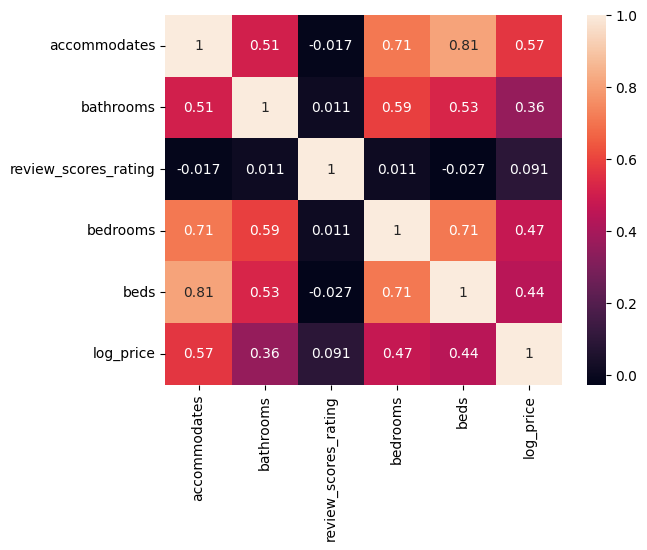

In [22]:
sns.heatmap(data[num].corr(),annot=True,fmt= '.2g')

In [24]:
t = data[num].corr()

In [25]:
type(t)

pandas.core.frame.DataFrame

In [27]:
t

,accommodates,bathrooms,review_scores_rating,bedrooms,beds,log_price
accommodates,1.000000,0.505632,-0.017128,0.709258,0.810801,0.567574
bathrooms,0.505632,1.000000,0.010537,0.589935,0.525591,0.355420
review_scores_rating,-0.017128,0.010537,1.000000,0.011143,-0.027330,0.091219
bedrooms,0.709258,0.589935,0.011143,1.000000,0.709416,0.473212
beds,0.810801,0.525591,-0.027330,0.709416,1.000000,0.442153
log_price,0.567574,0.355420,0.091219,0.473212,0.442153,1.000000


In [28]:
t.shape[0]

6

In [29]:
t.shape[1]

6

In [32]:
for i in range(t.shape[0]):
    for j in range(t.shape[1]):
        print(t.values[i,j])
    print("----------------")

1.0
0.5056324179602791
-0.01712757140061192
0.7092580388722244
0.8108007771672996
0.5675742149828118
----------------
0.5056324179602791
1.0
0.010537446046546512
0.5899351948201272
0.5255909807206923
0.3554196617879726
----------------
-0.01712757140061192
0.010537446046546512
1.0
0.011143059048836557
-0.02732998361139412
0.0912186391364838
----------------
0.7092580388722244
0.5899351948201272
0.011143059048836557
1.0
0.709415764586166
0.47321248800042975
----------------
0.8108007771672996
0.5255909807206923
-0.02732998361139412
0.709415764586166
1.0
0.442153334606664
----------------
0.5675742149828118
0.3554196617879726
0.0912186391364838
0.47321248800042975
0.442153334606664
1.0
----------------


<Axes: >

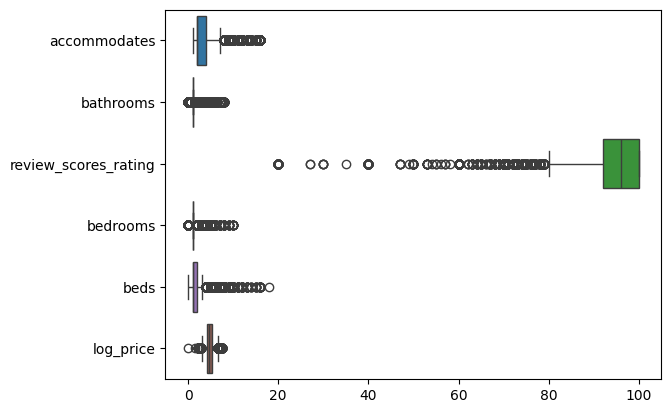

In [34]:
sns.boxplot(data[num],orient='h')

In [35]:
data[num].describe()

,accommodates,bathrooms,review_scores_rating,bedrooms,beds,log_price
count,74111.000000,73911.000000,57389.000000,74020.000000,73980.000000,74111.000000
mean,3.155146,1.235263,94.067365,1.265793,1.710868,4.782069
std,2.153589,0.582044,7.836556,0.852143,1.254142,0.717394
min,1.000000,0.000000,20.000000,0.000000,0.000000,0.000000
25%,2.000000,1.000000,92.000000,1.000000,1.000000,4.317488
50%,2.000000,1.000000,96.000000,1.000000,1.000000,4.709530
75%,4.000000,1.000000,100.000000,1.000000,2.000000,5.220356
max,16.000000,8.000000,100.000000,10.000000,18.000000,7.600402
